In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

In [2]:
# FOR ALL Large SCALE TRIALS
dx = 0.5e-6; #[m]
tau=1; #0.95; # best accuracy
vis=1e-3; #[pa*s]
rho=1e3; #[kg/m^3]
dt=(tau-0.5)/3*dx**2*rho/vis;
dm = rho*dx*dx*dx; # water mass
kBT=1.3806e-23*296; # thermal energy
Cube_Side_Length = 210; #[NU]
A_Cross = (Cube_Side_Length*dx)**2; # [m^2]
A_Cross_Small = (130*dx)**2;

L_0 = 210*dx;



Small_Forces = [];
# 1 [nN]:
Force_1 = .0277;
Small_Forces.append(Force_1);
# 5 [nN]:
Force_5 = .1388;
Small_Forces.append(Force_5);
# 10 [nN]:
Force_10 = .277;
Small_Forces.append(Force_10);
# 20 [nN]:
Force_20 = .5555;
Small_Forces.append(Force_20);
# 40 [nN]:
Force_40 = 1.1111;
Small_Forces.append(Force_40);
# 60 [nN]:
Force_60 = 1.6666;
Small_Forces.append(Force_60);
# 80 [nN]:
Force_80 = 2.2222;
Small_Forces.append(Force_80);
# 100 [nN]:
Force_100 = 2.7777777777777763;
Small_Forces.append(Force_100);


#For more forces:
Force_200 = 2*Force_100 
Small_Forces.append(Force_200);
Force_300 = 3*Force_100 
Small_Forces.append(Force_300);
Force_400 = 4*Force_100 
Small_Forces.append(Force_400);
Force_500 = 5*Force_100 
Small_Forces.append(Force_500);
Force_600 = 6*Force_100 
Small_Forces.append(Force_600);
Force_700 = 7*Force_100 
Small_Forces.append(Force_700);
Force_800 = 8*Force_100 
Small_Forces.append(Force_800);

Target_Stress = np.array(Small_Forces)*(1/(dt**2/dm/dx))/A_Cross_Small;

Small_Forces = Target_Stress*A_Cross*(dt**2/dm/dx)

print(Small_Forces)

[ 0.07228225  0.36219408  0.72282249  1.44955917  2.89937929  4.34893846
  5.79875858  7.24852071 14.49704142 21.74556213 28.99408284 36.24260355
 43.49112426 50.73964497 57.98816568]


In [3]:
# To calculate unitless force:
Force = 100e-9;

Force_LB = Force*dt**2/dm/dx;

print(Force_LB)

2.7777777777777763


0.43361904761904757   1.1826745562130188
0.5070333333333332   2.3602366863905346
0.6314523809523811   4.733254437869827
0.8416857142857145   9.467360946745568
1.0288333333333335   14.200615384615396
1.204052380952381   18.934721893491137
1.3684809523809522   23.66863905325444
1.982414285714286   47.33727810650888
2.3720761904761902   71.00591715976333
2.639995238095238   94.67455621301777
2.833338095238095   118.34319526627225
2.979533333333333   142.01183431952666
3.093438095238095   165.68047337278117
3.185309523809524   189.34911242603553


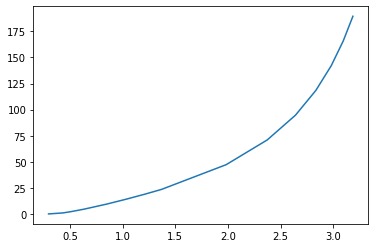

In [4]:
#Using Random Number Seed 1 Z stretch Small Scale
Tip_Num = 439;
Base_Num = 684;
Mobile_Num = 6910;

Tip_Forces = []
for i in range(0,len(Small_Forces),1):
    Tip_Force = Small_Forces[i]/Tip_Num;
    Tip_Forces.append(Tip_Force)
    #print('#fix             3 tip addforce',str(Tip_Force), '0 0') # For X
    #print('#fix             3 tip addforce 0 0 ', str(Tip_Force)) # For Z

#Unitless Force vs displacement Seed 1: Z direction
Force_Dp_1_Z = np.array([
    [272.325,Tip_Forces[0]],
    [301.06,Tip_Forces[1]],
    [316.477,Tip_Forces[2]],
    [342.605,Tip_Forces[3]],
    [386.754,Tip_Forces[4]],
    [426.055,Tip_Forces[5]],
    [462.851,Tip_Forces[6]], 
    [497.381,Tip_Forces[7]],
    [626.307,Tip_Forces[8]],
    [708.136,Tip_Forces[9]],
    [764.399,Tip_Forces[10]],
    [805.001,Tip_Forces[11]],
    [835.702,Tip_Forces[12]],
    [859.622,Tip_Forces[13]],
    [878.915,Tip_Forces[14]],
])

Force_Len_1_Z = [Force_Dp_1_Z[:,0]*dx,np.array(Small_Forces)*(1/(dt**2/dm/dx))]
Stress_Strain_1_Z = [(dx*Force_Dp_1_Z[:,0]-L_0)/L_0,np.array(Small_Forces)*(1/(dt**2/dm/dx))/A_Cross]

plt.plot(Stress_Strain_1_Z[0],Stress_Strain_1_Z[1])
for i in range(1,len(Stress_Strain_1_Z[0]),1):
    stress = Stress_Strain_1_Z[0][i];
    strain = Stress_Strain_1_Z[1][i];
    print(str(stress),' ',str(strain))

0.36772380952380945   1.1826745562130188
0.4539857142857143   2.3602366863905346
0.5874380952380955   4.733254437869827
0.8137666666666669   9.467360946745568
1.0121952380952381   14.200615384615396
1.197352380952381   18.934721893491137
1.3620809523809523   23.66863905325444
1.9650476190476187   47.33727810650888
2.3207761904761908   71.00591715976333
2.5452047619047624   94.67455621301777
2.69072380952381   118.34319526627225
2.810161904761905   142.01183431952666
2.91792380952381   165.68047337278117
3.0016285714285718   189.34911242603553


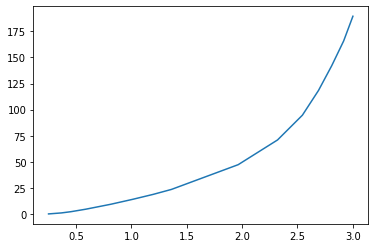

In [5]:
#Using Random Number Seed 1 X stretch
Tip_Num = 405;
Base_Num = 689;
Mobile_Num = 6905;

Tip_Forces = []
for i in range(0,len(Small_Forces),1):
    Tip_Force = Small_Forces[i]/Tip_Num;
    #print('#fix             7 tip addforce',str(Tip_Force), '0 0')
    Tip_Forces.append(Tip_Force)

#Unitless Force vs displacement Seed 1: X direction
Force_Dp_1_X = np.array([
    [262.861,Tip_Forces[0]],
    [287.222,Tip_Forces[1]],
    [305.337,Tip_Forces[2]],
    [333.362,Tip_Forces[3]],
    [380.891,Tip_Forces[4]],
    [422.561,Tip_Forces[5]],
    [461.444,Tip_Forces[6]], 
    [496.037,Tip_Forces[7]],
    [622.66,Tip_Forces[8]],
    [697.363,Tip_Forces[9]],
    [744.493,Tip_Forces[10]],
    [775.052,Tip_Forces[11]],
    [800.134,Tip_Forces[12]],
    [822.764,Tip_Forces[13]],
    [840.342,Tip_Forces[14]],
])

Force_Len_1_X = [Force_Dp_1_X[:,0]*dx,np.array(Small_Forces)*(1/(dt**2/dm/dx))]
Stress_Strain_1_X = [(dx*Force_Dp_1_X[:,0]-L_0)/L_0,np.array(Small_Forces)*(1/(dt**2/dm/dx))/A_Cross]

#print(Stress_Strain_1_X)

plt.plot(Stress_Strain_1_X[0],Stress_Strain_1_X[1])
for i in range(1,len(Stress_Strain_1_X[0]),1):
    stress = Stress_Strain_1_X[0][i];
    strain = Stress_Strain_1_X[1][i];
    print(str(stress),' ',str(strain))

#fix             3 tip addforce 0  0.00017501755089760303  0
#fix             3 tip addforce 0  0.0008769832514291446  0
#fix             3 tip addforce 0  0.0017501755089760309  0
#fix             3 tip addforce 0  0.003509828502657708  0
#fix             3 tip addforce 0  0.0070202888376291244  0
#fix             3 tip addforce 0  0.010530117340286834  0
#fix             3 tip addforce 0  0.014040577675258249  0
#fix             3 tip addforce 0  0.017550897603048832  0
#fix             3 tip addforce 0  0.035101795206097665  0
#fix             3 tip addforce 0  0.0526526928091465  0
#fix             3 tip addforce 0  0.07020359041219533  0
#fix             3 tip addforce 0  0.08775448801524419  0
#fix             3 tip addforce 0  0.105305385618293  0
#fix             3 tip addforce 0  0.12285628322134186  0
#fix             3 tip addforce 0  0.14040718082439066  0
0.4141190476190475   1.1826745562130188
0.5112   2.3602366863905346
0.6649047619047619   4.733254437869827
0.8960238095

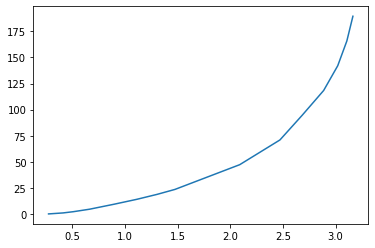

In [11]:
#Using Random Number Seed 1 Y stretch Small Scale
Tip_Num = 413;
Base_Num = 665;
Mobile_Num = 6929;

Tip_Forces = []
for i in range(0,len(Small_Forces),1):
    Tip_Force = Small_Forces[i]/Tip_Num;
    Tip_Forces.append(Tip_Force)
    #print('#fix             3 tip addforce',str(Tip_Force), '0 0') # For X
    print('#fix             3 tip addforce 0 ',str(Tip_Force),' 0') # For Y
    #print('#fix             3 tip addforce 0 0 ', str(Tip_Force)) # For Z

#Unitless Force vs displacement Seed 1: Z direction
Force_Dp_1_Z = np.array([
    [267.969,Tip_Forces[0]],
    [296.965,Tip_Forces[1]],
    [317.352,Tip_Forces[2]],
    [349.63,Tip_Forces[3]],
    [398.165,Tip_Forces[4]],
    [443.84,Tip_Forces[5]],
    [484.227,Tip_Forces[6]], #50 nN
    [519.826,Tip_Forces[7]],
    [648.895,Tip_Forces[8]],
    [729.055,Tip_Forces[9]],
    [773.482,Tip_Forces[10]],
    [816.196,Tip_Forces[11]],
    [844.232,Tip_Forces[12]],
    [862.371,Tip_Forces[13]],
    [874.457,Tip_Forces[14]],
])

Force_Len_1_Z = [Force_Dp_1_Z[:,0]*dx,np.array(Small_Forces)*(1/(dt**2/dm/dx))]
Stress_Strain_1_Z = [(dx*Force_Dp_1_Z[:,0]-L_0)/L_0,np.array(Small_Forces)*(1/(dt**2/dm/dx))/A_Cross]

plt.plot(Stress_Strain_1_Z[0],Stress_Strain_1_Z[1])
for i in range(1,len(Stress_Strain_1_Z[0]),1):
    stress = Stress_Strain_1_Z[0][i];
    strain = Stress_Strain_1_Z[1][i];
    print(str(stress),' ',str(strain))